# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import asyncio
from tqdm.asyncio import tqdm_asyncio
import time
import seaborn as sns

## Download nltk dependencies
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

## EDA Libraries
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

# Text Preprocessing Libraries
import re
import string
import contractions
import emoji
from deep_translator import GoogleTranslator

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/vanlian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/vanlian/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Import Data

In [3]:
df = pd.read_csv("../dataset/main_dataset/data.csv")
df

,title,description
0,10 + Blockchain Nodes / Masternodes to set up,*Requirements*\r\n\r\nWe're looking for a long...
1,10 .NET Developers (Middle and Senior level),"Greetings! My name is Maria, I am in urgent ne..."
2,"10X Engineer (co-founder, #4 employee, USD 11-...",**Product**\r\nThe product is a live video cha...
3,16 - Amazon Brand Manager,"Currently, TCM expanding its activities to Ukr..."
4,16 - Amazon Brand Manager,"Hello,\r\nWe, MIMIRB2B, are an outstaff compan..."
...,...,...
151811,Apprentice Program,**Apprentice Program**\n\n\n* Full-time\n* Leg...
151812,"Environmental, Health and Safety (EHS) Special...","**Environmental, Health and Safety (EHS) Speci..."
151813,Technology & Quality Expert in Purchasing,**Technology & Quality Expert in Purchasing**\...
151814,Extracurricular Internship: Test Management (f...,**Extracurricular Internship: Test Management ...


# Data Glipse

In [4]:
df.head()

,title,description
0,10 + Blockchain Nodes / Masternodes to set up,*Requirements*\r\n\r\nWe're looking for a long...
1,10 .NET Developers (Middle and Senior level),"Greetings! My name is Maria, I am in urgent ne..."
2,"10X Engineer (co-founder, #4 employee, USD 11-...",**Product**\r\nThe product is a live video cha...
3,16 - Amazon Brand Manager,"Currently, TCM expanding its activities to Ukr..."
4,16 - Amazon Brand Manager,"Hello,\r\nWe, MIMIRB2B, are an outstaff compan..."


# Checking Missing Value

In [5]:
df.isnull().sum()

title            0
description    112
dtype: int64

# Check Duplicate Data

In [6]:
# Returns the total count of duplicate rows
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 1267


# WordCloud

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151816 entries, 0 to 151815
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   title        151816 non-null  str  
 1   description  151704 non-null  str  
dtypes: str(2)
memory usage: 284.2 MB


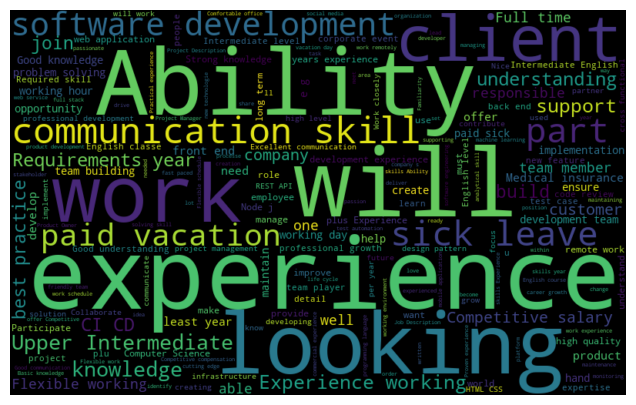

In [8]:
text = ' '.join(
    df['description']
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda x: x != '']
)
wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='black',
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Label Distribution

In [9]:
df['description'] = df['description'].fillna("")
df['char_count'] = df['description'].apply(len)

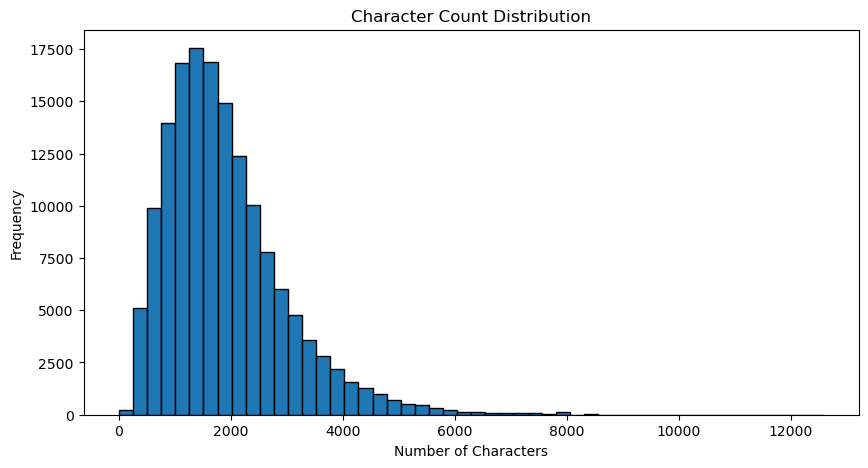

In [10]:
plt.figure(figsize=(10,5))
plt.hist(df['char_count'], bins=50, edgecolor='black')
plt.title("Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [11]:
df['text'] = df['title'].fillna('') + " " + df['description'].fillna('')

In [12]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

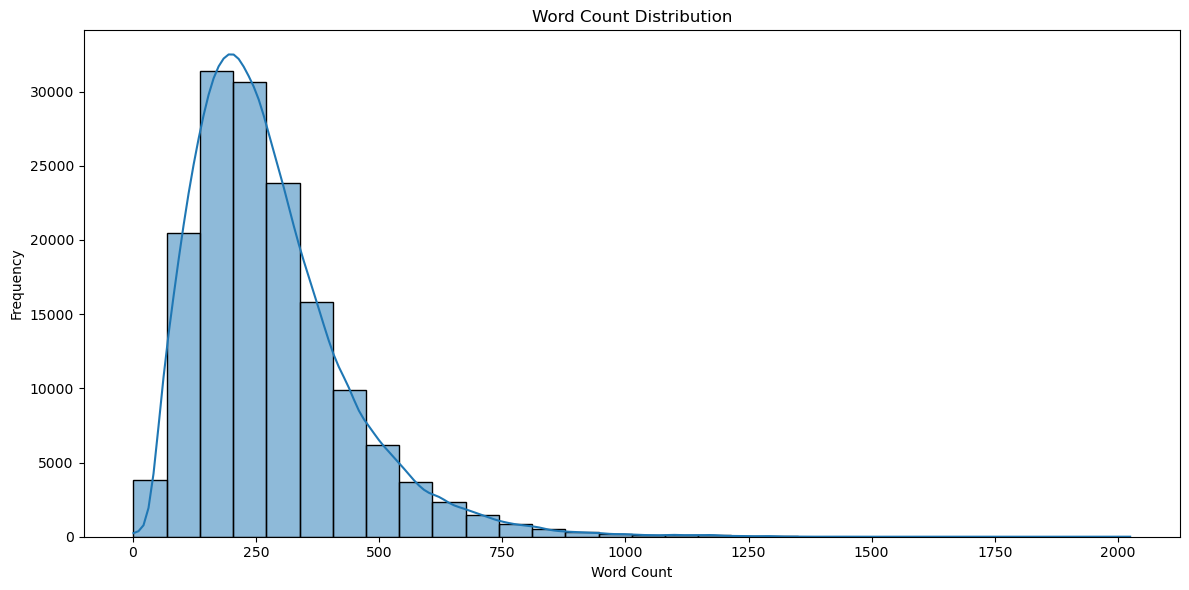

In [13]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    kde=True   # optional, biar ada curve
)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
import re
import string
import contractions
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(
    text: str,
    tokenize: bool = False,
    remove_stop_words: bool = False,
    stem_words: bool = False,
    remove_url: bool = False,
    remove_numbers: bool = False,
    remove_emojis: str = "convert"
):
    """
    Improved text cleaning function for NLP tasks (English-focused).
    """

    # --- Basic cleaning ---
    text = str(text)
    text = contractions.fix(text)
    text = text.lower().strip()

    # --- Remove URL ---
    if remove_url:
        text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # --- Normalize repeated characters ---
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # --- Handle emojis ---
    if remove_emojis.lower() == "remove":
        text = emoji.replace_emoji(text, replace='')
    elif remove_emojis.lower() == "convert":
        text = emoji.demojize(text)

    # --- Remove numbers (optional) ---
    if remove_numbers:
        text = re.sub(r'\d+', '', text)

    # --- Clean special characters ---
    text = re.sub(r"[^a-z0-9_:\s']", " ", text)  # keep : for emoji text
    text = re.sub(r'\s+', ' ', text).strip()

    # --- Tokenize ---
    tokens = word_tokenize(text)

    # --- Stemming (before stopword removal) ---
    if stem_words:
        tokens = [stemmer.stem(t) for t in tokens]

    # --- Remove stopwords ---
    if remove_stop_words:
        tokens = [w for w in tokens if w not in stop_words]

    # --- Return ---
    return tokens if tokenize else " ".join(tokens)

# Export Cleaned Data

In [15]:
import os
import pandas as pd
from tqdm import tqdm
import nltk

# Make sure your clean_text function is defined somewhere above
# from your_module import clean_text  # Uncomment if clean_text is in another file

# Download necessary NLTK resources
nltk.download('punkt')
# nltk.download('punkt_tab')  # Only if you actually need this; sometimes not available

# Enable tqdm progress_apply for pandas
tqdm.pandas()

# Example: load your data (replace with your actual data loading)
# df = pd.read_csv("raw_data.csv")  # Replace with your raw data path

# Apply text cleaning with progress bar
df["cleaned_text"] = df["text"].progress_apply(
    lambda x: clean_text(
        x,
        remove_stop_words=True,
        stem_words=False,
        remove_url=True,
        remove_numbers=True
    )
)

# Create dataset folder outside the current folder
output_dir = os.path.join("..", "dataset")  # ".." means one level up
os.makedirs(output_dir, exist_ok=True)

# Save cleaned data
output_file = os.path.join(output_dir, "cleaned_data.csv")
df.to_csv(output_file, index=False)
print("Cleaned data disimpan di:", output_file)

[nltk_data] Downloading package punkt to /home/vanlian/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████| 151816/151816 [05:29<00:00, 461.32it/s]


Cleaned data disimpan di: ../dataset/cleaned_data.csv
